# Teeth Masking — Preprocessing dari Mask Roboflow

Mengubah anotasi segmentasi gigi (RLE COCO dari notebook 11) menjadi input ter-masking:
**background hitam, gigi tetap di posisi asal** (susunan & spacing terjaga). Menghasilkan
dua varian di `data/`:

- `data/masked/{split}/`      — masked, **frame penuh** (hanya masking; membandingkan efek masking saja).
- `data/masked_crop/{split}/` — masked **+ crop ketat** ke bbox gigi (gigi memenuhi frame).

Nama file dikembalikan ke nama OMNI asli (strip suffix `.rf.<hash>`), agar mudah dipetakan
di notebook 10. Butuh `pycocotools` (dekode RLE).

In [1]:
import os, json, glob, sys, subprocess
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
try:
    from pycocotools import mask as coco_mask
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pycocotools']); from pycocotools import mask as coco_mask

try:    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError: _HERE = os.getcwd()
PROJECT_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == 'notebooks' else _HERE
DATA_RAW  = os.path.join(PROJECT_ROOT, 'data', 'raw')
DIR_MASK  = os.path.join(PROJECT_ROOT, 'data', 'masks')     # hasil download Roboflow (nb 11)
DIR_OUT_FULL = os.path.join(PROJECT_ROOT, 'data', 'masked')
DIR_OUT_CROP = os.path.join(PROJECT_ROOT, 'data', 'masked_crop')
PAD = 0.04        # padding crop (fraksi)
SPLITS = ['train', 'val', 'test']
assert os.path.isdir(DIR_MASK), 'data/masks belum ada — jalankan notebook 11 dulu.'
print('sumber mask:', os.path.relpath(DIR_MASK, PROJECT_ROOT))

sumber mask: data/masks



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
def nama_asli(fn):
    """namaOMNI dari nama Roboflow: 2018..._JPG.rf.<hash>.jpg -> 2018....JPG"""
    base = fn.split('.rf.')[0]; stem, ext = base.rsplit('_', 1); return f'{stem}.{ext}'

def cari_raw(split, on):
    for cand in [on, on[:-4] + '.jpg', on[:-4] + '.JPG']:
        p = os.path.join(DATA_RAW, split, cand)
        if os.path.exists(p): return p
    return None

def union_mask(segs):
    m = None
    for s in segs:
        d = coco_mask.decode(s).astype(bool)
        m = d if m is None else (m | d)
    return m

In [3]:
for d in (DIR_OUT_FULL, DIR_OUT_CROP):
    for s in SPLITS: os.makedirs(os.path.join(d, s), exist_ok=True)

lapor = {}
for split in SPLITS:
    jp = glob.glob(os.path.join(DIR_MASK, split, '**', '_annotations.coco.json'), recursive=True)[0]
    dj = json.load(open(jp))
    tooth_id = [c['id'] for c in dj['categories'] if c['name'] == 'tooth'][0]
    byimg = {}
    for a in dj['annotations']:
        if a['category_id'] == tooth_id: byimg.setdefault(a['image_id'], []).append(a['segmentation'])
    ok = miss = 0
    for im in dj['images']:
        segs = byimg.get(im['id'])
        on = nama_asli(im['file_name']); rawp = cari_raw(split, on)
        if not segs or rawp is None: miss += 1; continue
        img = np.asarray(Image.open(rawp).convert('RGB'))
        H, W = im['height'], im['width']
        um = union_mask(segs)
        if um.shape != img.shape[:2]:                       # jaga-jaga bila ukuran beda
            um = np.asarray(Image.fromarray(um.astype('uint8')*255).resize((img.shape[1], img.shape[0]))) > 127
        masked = img * um[..., None]
        Image.fromarray(masked).save(os.path.join(DIR_OUT_FULL, split, on), quality=95)
        ys, xs = np.where(um)
        dx, dy = int((xs.max()-xs.min())*PAD), int((ys.max()-ys.min())*PAD)
        x0, x1 = max(xs.min()-dx, 0), min(xs.max()+dx, W); y0, y1 = max(ys.min()-dy, 0), min(ys.max()+dy, H)
        Image.fromarray(masked[y0:y1, x0:x1]).save(os.path.join(DIR_OUT_CROP, split, on), quality=95)
        ok += 1
    lapor[split] = (ok, miss)
    print(f'{split:5s}: {ok} tersimpan | {miss} dilewati (tak ada mask/raw)')
print('\nmasked (frame penuh) ->', os.path.relpath(DIR_OUT_FULL, PROJECT_ROOT))
print('masked + crop        ->', os.path.relpath(DIR_OUT_CROP, PROJECT_ROOT))

train: 374 tersimpan | 0 dilewati (tak ada mask/raw)
val  : 74 tersimpan | 1 dilewati (tak ada mask/raw)
test : 106 tersimpan | 0 dilewati (tak ada mask/raw)

masked (frame penuh) -> data/masked
masked + crop        -> data/masked_crop


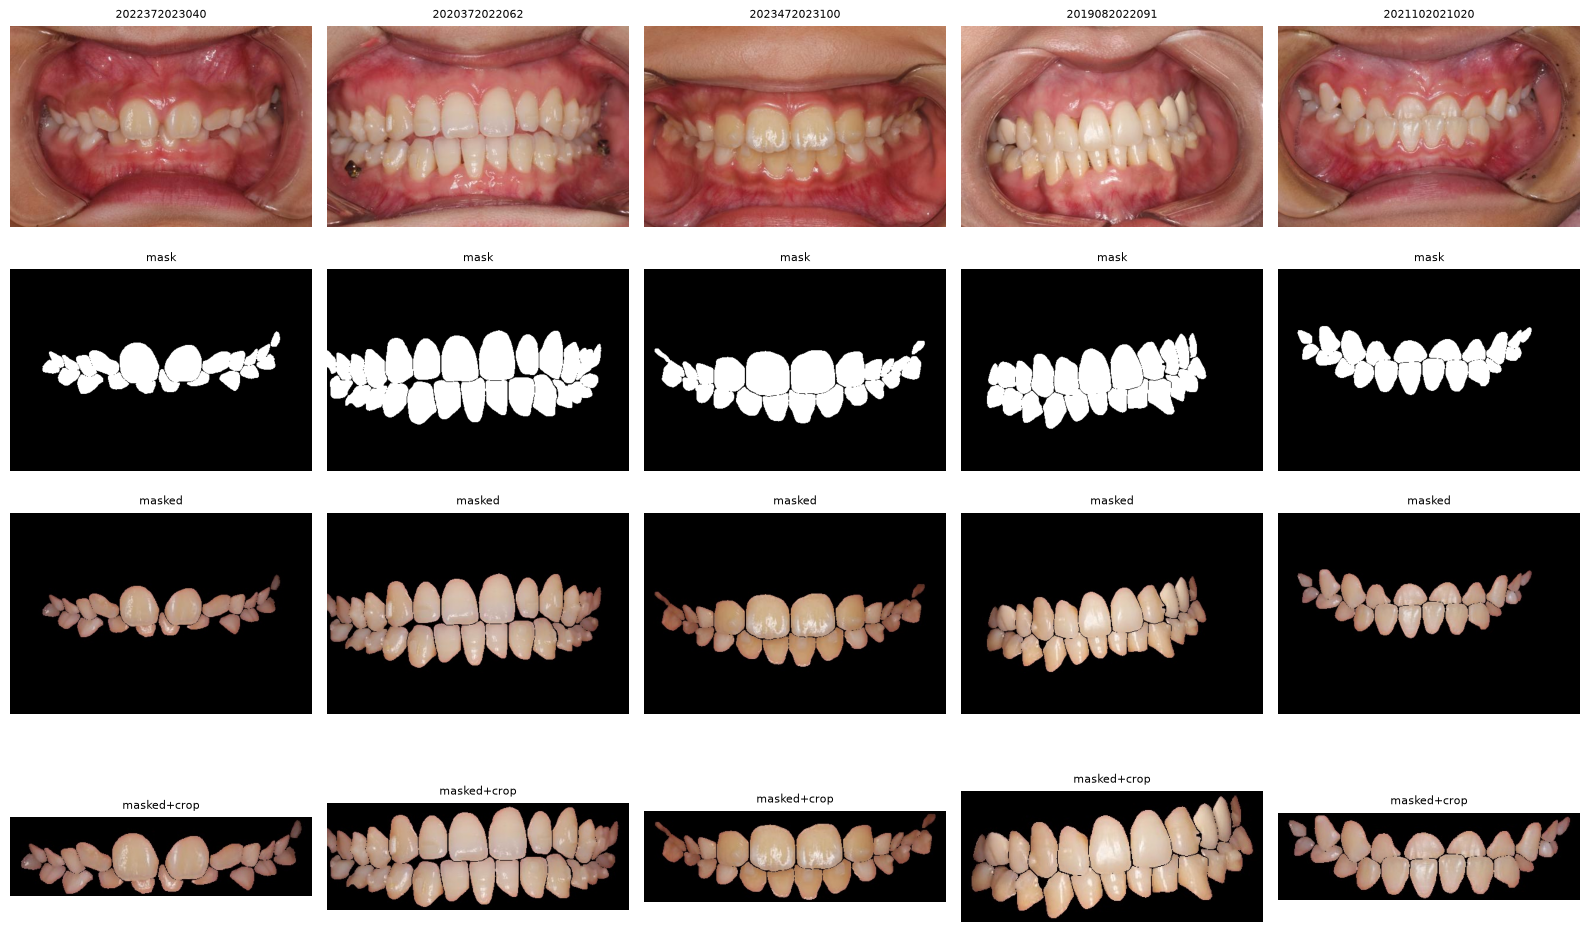

In [4]:
# sanity-check: asli / mask / masked / masked+crop
split = 'train'
jp = glob.glob(os.path.join(DIR_MASK, split, '**', '_annotations.coco.json'), recursive=True)[0]
dj = json.load(open(jp)); tooth_id = [c['id'] for c in dj['categories'] if c['name']=='tooth'][0]
byimg = {}
for a in dj['annotations']:
    if a['category_id']==tooth_id: byimg.setdefault(a['image_id'], []).append(a['segmentation'])
fig, ax = plt.subplots(4, 5, figsize=(16, 10))
cols = list(dj['images'])[:5]
for k, im in enumerate(cols):
    on = nama_asli(im['file_name'])
    img = np.asarray(Image.open(cari_raw(split, on)).convert('RGB'))
    um = union_mask(byimg[im['id']])
    ax[0,k].imshow(img); ax[0,k].set_title(on[:13], fontsize=8)
    ax[1,k].imshow(um, cmap='gray'); ax[1,k].set_title('mask', fontsize=8)
    ax[2,k].imshow(Image.open(os.path.join(DIR_OUT_FULL, split, on))); ax[2,k].set_title('masked', fontsize=8)
    ax[3,k].imshow(Image.open(os.path.join(DIR_OUT_CROP, split, on))); ax[3,k].set_title('masked+crop', fontsize=8)
    for r in range(4): ax[r,k].axis('off')
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'teeth_masking_preview.png'), dpi=110, bbox_inches='tight'); plt.show()

## Langkah berikutnya (notebook 10)

Tambah saklar `INPUT_MODE`:
- `full` → `data/raw`
- `teeth_masked` → `data/masked`
- `teeth_masked_crop` → `data/masked_crop`

Dataset tinggal menukar folder dasar (nama file sama). Lalu bandingkan lewat
**cross-validation (QWK OOF)**: `full` vs `teeth_masked` vs `teeth_masked_crop`.